# 4.3.2. Сравнение bSB и dSB на малых случайных Ising-моделях

В этой тетрадке проводится сравнение двух вариантов simulated bifurcation:

- bSB - ballistic simulated bifurcation;
- dSB - discrete simulated bifurcation.

В отличие от предыдущей тетрадки, здесь рассматриваются не только простые модели с очевидным оптимумом, а случайные малые Ising-модели. Для каждой задачи точный минимум находится полным перебором, после чего результаты bSB и dSB сравниваются с точным решением.

Целевая функция:

$$
E(s) = - \sum_{i<j} J_{ij}s_i s_j - \sum_i h_i s_i,
\qquad
s_i \in \{-1,+1\}.
$$

Основные метрики:

- вероятность нахождения точного оптимума;
- средний энергетический разрыв;
- медианный энергетический разрыв;
- лучший найденный разрыв;
- среднее время одного запуска.

In [1]:
import numpy as np
import pandas as pd
import itertools
import time
import matplotlib.pyplot as plt
import sys

sys.path.append('курсовая_2')
from SB_modules import BSB, DSB

In [2]:
def ising_energy(s, J, h=None):
    s = np.asarray(s, dtype=int).reshape(-1)
    J = np.asarray(J, dtype=float)

    if h is None:
        h = np.zeros_like(s, dtype=float)
    else:
        h = np.asarray(h, dtype=float).reshape(-1)

    pair_term = 0.0
    N = len(s)

    for i in range(N):
        for j in range(i + 1, N):
            pair_term += J[i, j] * s[i] * s[j]

    field_term = np.dot(h, s)

    return float(-pair_term - field_term)


def brute_force_ising(J, h=None):
    J = np.asarray(J, dtype=float)
    N = J.shape[0]

    if h is None:
        h = np.zeros(N, dtype=float)
    else:
        h = np.asarray(h, dtype=float).reshape(-1)

    best_energy = np.inf
    best_states = []

    for s_tuple in itertools.product([-1, 1], repeat=N):
        s = np.array(s_tuple, dtype=int)
        E = ising_energy(s, J, h)

        if E < best_energy - 1e-12:
            best_energy = E
            best_states = [s]
        elif abs(E - best_energy) <= 1e-12:
            best_states.append(s)

    return best_energy, best_states

In [3]:
def generate_random_ising_instance(N, seed=None, p_edge=1.0, with_field=False):
    """
    Генерирует случайную Ising-модель.

    Parameters
    ----------
    N : int
        Число спинов.
    seed : int
        Seed для воспроизводимости.
    p_edge : float
        Вероятность наличия ребра. p_edge=1.0 даёт полный граф.
    with_field : bool
        Если True, добавляет случайное локальное поле.

    Returns
    -------
    J : ndarray, shape (N, N)
    h : ndarray, shape (N,)
    """
    rng = np.random.default_rng(seed)

    J = np.zeros((N, N), dtype=float)

    for i in range(N):
        for j in range(i + 1, N):
            if rng.random() <= p_edge:
                val = rng.choice([-1.0, 1.0])
                J[i, j] = val
                J[j, i] = val

    if with_field:
        h = rng.uniform(-0.5, 0.5, size=N)
    else:
        h = np.zeros(N, dtype=float)

    return J, h

In [4]:
def run_sb_many(
    J,
    h=None,
    variant="BSB",
    n_runs=30,
    n_iter=1000,
    dt=0.05,
    seed=42,
):
    J = np.asarray(J, dtype=float)
    N = J.shape[0]

    if h is None:
        h = np.zeros((N, 1), dtype=float)
    else:
        h = np.asarray(h, dtype=float).reshape(N, 1)

    rows = []

    for r in range(n_runs):
        run_seed = seed + r

        if variant.upper() == "BSB":
            solver = BSB(J, h=h, n_iter=n_iter, dt=dt, seed=run_seed)
        elif variant.upper() == "DSB":
            solver = DSB(J, h=h, n_iter=n_iter, dt=dt, seed=run_seed)
        else:
            raise ValueError("variant must be 'BSB' or 'DSB'")

        start = time.perf_counter()
        solver.run(record_trajectory=False)
        elapsed = time.perf_counter() - start

        x_final = solver.x.reshape(-1)
        s_final = np.where(x_final >= 0, 1, -1)

        E = ising_energy(s_final, J, h.reshape(-1))

        rows.append({
            "variant": variant.upper(),
            "run": r,
            "seed": run_seed,
            "energy": E,
            "state": tuple(s_final.tolist()),
            "runtime_sec": elapsed,
        })

    return pd.DataFrame(rows)

In [5]:
def evaluate_random_instance(
    N,
    instance_id,
    J,
    h,
    n_runs=30,
    n_iter=1000,
    dt=0.05,
    seed=42,
):
    """
    Для одной случайной Ising-модели:
    1. находит точный минимум brute force;
    2. запускает BSB;
    3. запускает DSB;
    4. возвращает агрегированные метрики.
    """
    E_exact, exact_states = brute_force_ising(J, h)

    rows = []

    for variant in ["BSB", "DSB"]:
        df = run_sb_many(
            J=J,
            h=h,
            variant=variant,
            n_runs=n_runs,
            n_iter=n_iter,
            dt=dt,
            seed=seed,
        )

        gaps = df["energy"].values - E_exact

        rows.append({
            "N": N,
            "instance_id": instance_id,
            "variant": variant,
            "E_exact": E_exact,
            "E_best": df["energy"].min(),
            "mean_energy": df["energy"].mean(),
            "success_rate": np.mean(np.isclose(df["energy"], E_exact)),
            "mean_gap": np.mean(gaps),
            "median_gap": np.median(gaps),
            "best_gap": np.min(gaps),
            "max_gap": np.max(gaps),
            "mean_runtime_sec": df["runtime_sec"].mean(),
            "n_exact_states": len(exact_states),
        })

    return pd.DataFrame(rows)

In [6]:
N_VALUES = [4, 6, 8, 10, 12]
N_INSTANCES_PER_N = 10

N_RUNS = 30
N_ITER = 1000
DT = 0.05
BASE_SEED = 42

P_EDGE = 1.0
WITH_FIELD = False

In [7]:
all_results = []

for N in N_VALUES:
    print(f"Running N={N}")

    for instance_id in range(N_INSTANCES_PER_N):
        instance_seed = BASE_SEED + 1000 * N + instance_id

        J, h = generate_random_ising_instance(
            N=N,
            seed=instance_seed,
            p_edge=P_EDGE,
            with_field=WITH_FIELD,
        )

        res = evaluate_random_instance(
            N=N,
            instance_id=instance_id,
            J=J,
            h=h,
            n_runs=N_RUNS,
            n_iter=N_ITER,
            dt=DT,
            seed=BASE_SEED + 10_000 * N + instance_id * 100,
        )

        all_results.append(res)

results_432_raw = pd.concat(all_results, ignore_index=True)

results_432_raw.head()

Running N=4
Running N=6
Running N=8
Running N=10
Running N=12


,N,instance_id,variant,E_exact,E_best,mean_energy,success_rate,mean_gap,median_gap,best_gap,max_gap,mean_runtime_sec,n_exact_states
0,4,0,BSB,-4.0,-4.0,-4.0,1.0,0.0,0.0,0.0,0.0,0.028212,2
1,4,0,DSB,-4.0,-4.0,-4.0,1.0,0.0,0.0,0.0,0.0,0.028504,2
2,4,1,BSB,-6.0,-6.0,-6.0,1.0,0.0,0.0,0.0,0.0,0.027335,2
3,4,1,DSB,-6.0,-6.0,-6.0,1.0,0.0,0.0,0.0,0.0,0.028377,2
4,4,2,BSB,-4.0,-4.0,-4.0,1.0,0.0,0.0,0.0,0.0,0.027768,2


In [8]:
summary_432 = (
    results_432_raw
    .groupby(["N", "variant"], as_index=False)
    .agg(
        mean_success_rate=("success_rate", "mean"),
        median_success_rate=("success_rate", "median"),
        mean_gap=("mean_gap", "mean"),
        median_gap=("median_gap", "mean"),
        mean_best_gap=("best_gap", "mean"),
        mean_runtime_sec=("mean_runtime_sec", "mean"),
        n_instances=("instance_id", "nunique"),
    )
)

summary_432["mean_runtime_ms"] = 1000 * summary_432["mean_runtime_sec"]
summary_432 = summary_432.drop(columns=["mean_runtime_sec"])

summary_432

,N,variant,mean_success_rate,median_success_rate,mean_gap,median_gap,mean_best_gap,n_instances,mean_runtime_ms
0,4,BSB,1.000000,1.000000,0.000000,0.0,0.0,10,27.712699
1,4,DSB,1.000000,1.000000,0.000000,0.0,0.0,10,28.479698
2,6,BSB,0.993333,1.000000,0.013333,0.0,0.0,10,27.834629
3,6,DSB,0.996667,1.000000,0.006667,0.0,0.0,10,28.565178
4,8,BSB,0.913333,1.000000,0.173333,0.2,0.0,10,27.849212
5,8,DSB,0.953333,0.966667,0.206667,0.0,0.0,10,28.577861
6,10,BSB,0.916667,1.000000,0.166667,0.2,0.0,10,28.101299
7,10,DSB,0.853333,0.916667,0.400000,0.0,0.0,10,28.813957
8,12,BSB,0.990000,1.000000,0.020000,0.0,0.0,10,28.843833
9,12,DSB,0.773333,0.816667,0.706667,0.4,0.0,10,29.630335


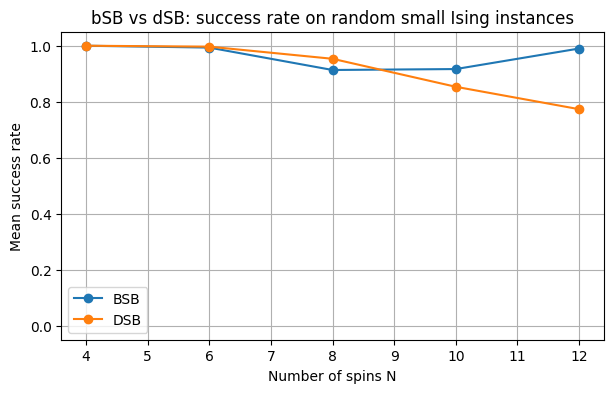

In [9]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_432[summary_432["variant"] == variant]
    plt.plot(
        part["N"],
        part["mean_success_rate"],
        marker="o",
        label=variant,
    )

plt.xlabel("Number of spins N")
plt.ylabel("Mean success rate")
plt.title("bSB vs dSB: success rate on random small Ising instances")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()

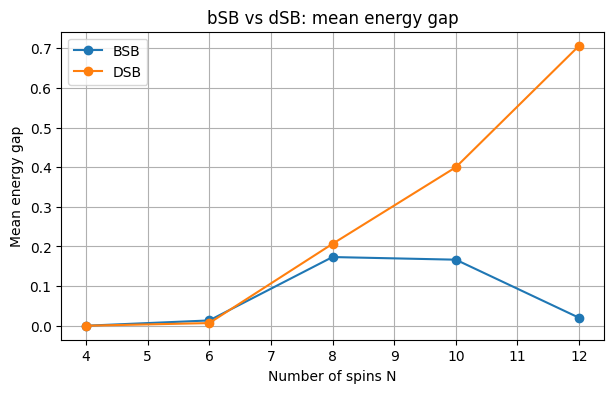

In [10]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_432[summary_432["variant"] == variant]
    plt.plot(
        part["N"],
        part["mean_gap"],
        marker="o",
        label=variant,
    )

plt.xlabel("Number of spins N")
plt.ylabel("Mean energy gap")
plt.title("bSB vs dSB: mean energy gap")
plt.grid(True)
plt.legend()
plt.show()

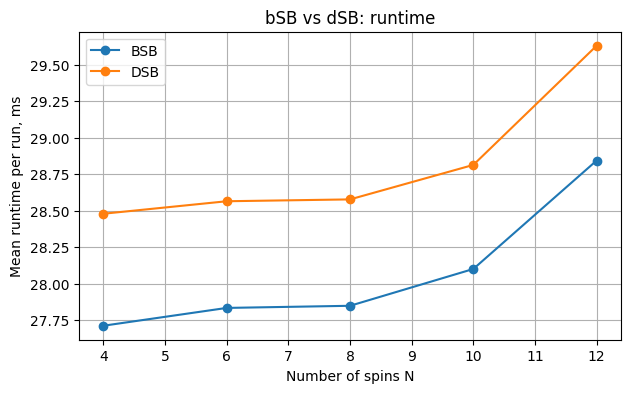

In [11]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_432[summary_432["variant"] == variant]
    plt.plot(
        part["N"],
        part["mean_runtime_ms"],
        marker="o",
        label=variant,
    )

plt.xlabel("Number of spins N")
plt.ylabel("Mean runtime per run, ms")
plt.title("bSB vs dSB: runtime")
plt.grid(True)
plt.legend()
plt.show()


In [12]:
results_432_raw.to_csv(
    "results_04_03_02_bsb_vs_dsb_raw.csv",
    index=False,
)

summary_432.to_csv(
    "summary_04_03_02_bsb_vs_dsb.csv",
    index=False,
)

print("Saved:")
print("results_04_03_02_bsb_vs_dsb_raw.csv")
print("summary_04_03_02_bsb_vs_dsb.csv")

Saved:
results_04_03_02_bsb_vs_dsb_raw.csv
summary_04_03_02_bsb_vs_dsb.csv


На малых случайных Ising-моделях оба варианта SB способны находить глобальный минимум, однако вероятность успеха одного запуска зависит от размерности и варианта динамики. В выбранной конфигурации параметров bSB оказался более устойчивым при росте размерности до N=12, тогда как dSB не показал однозначного преимущества на данном классе случайных плотных задач.

## Быстрый brute force для больших малых N

In [13]:
def brute_force_ising_chunked(J, h=None, chunk_size=200_000):
    """
    Ускоренный brute force по всем 2^N конфигурациям.

    Подходит для N примерно до 22.
    Энергия:
        E(s) = -1/2 s^T J s - h^T s,
    где J симметричная, diag(J)=0.
    """
    J = np.asarray(J, dtype=float)
    N = J.shape[0]

    if h is None:
        h = np.zeros(N, dtype=float)
    else:
        h = np.asarray(h, dtype=float).reshape(-1)

    total = 1 << N
    best_energy = np.inf
    best_states = []

    powers = (1 << np.arange(N, dtype=np.uint64))

    for start in range(0, total, chunk_size):
        end = min(start + chunk_size, total)

        nums = np.arange(start, end, dtype=np.uint64)[:, None]
        bits = ((nums & powers) > 0).astype(np.int8)

        # bits in {0,1} -> spins in {-1,+1}
        S = 2 * bits - 1
        S = S.astype(float)

        pair_energy = -0.5 * np.sum((S @ J) * S, axis=1)
        field_energy = -(S @ h)
        energies = pair_energy + field_energy

        local_min = energies.min()

        if local_min < best_energy - 1e-12:
            best_energy = float(local_min)
            best_states = []

            idxs = np.where(np.isclose(energies, best_energy))[0]
            for idx in idxs:
                best_states.append(S[idx].astype(int))

        elif np.isclose(local_min, best_energy):
            idxs = np.where(np.isclose(energies, best_energy))[0]
            for idx in idxs:
                best_states.append(S[idx].astype(int))

    return best_energy, best_states

Проверка, что быстрый brute force совпадает со старым

In [14]:
J_test, h_test = generate_random_ising_instance(
    N=8,
    seed=123,
    p_edge=1.0,
    with_field=False,
)

E_old, states_old = brute_force_ising(J_test, h_test)
E_fast, states_fast = brute_force_ising_chunked(J_test, h_test)

E_old, E_fast, len(states_old), len(states_fast)

(-12.0, -12.0, 2, 2)

In [15]:
def evaluate_random_instance_exact_chunked(
    N,
    instance_id,
    J,
    h,
    n_runs=50,
    n_iter=1000,
    dt=0.05,
    seed=42,
    chunk_size=200_000,
):
    """
    Оценка одной случайной Ising-модели с точным optimum,
    найденным ускоренным brute force.
    """
    E_exact, exact_states = brute_force_ising_chunked(
        J,
        h,
        chunk_size=chunk_size,
    )

    rows = []

    for variant in ["BSB", "DSB"]:
        df = run_sb_many(
            J=J,
            h=h,
            variant=variant,
            n_runs=n_runs,
            n_iter=n_iter,
            dt=dt,
            seed=seed,
        )

        gaps = df["energy"].values - E_exact

        rows.append({
            "N": N,
            "instance_id": instance_id,
            "variant": variant,
            "E_exact": E_exact,
            "E_best": df["energy"].min(),
            "mean_energy": df["energy"].mean(),
            "success_rate": np.mean(np.isclose(df["energy"], E_exact)),
            "mean_gap": np.mean(gaps),
            "median_gap": np.median(gaps),
            "best_gap": np.min(gaps),
            "max_gap": np.max(gaps),
            "mean_runtime_sec": df["runtime_sec"].mean(),
            "n_exact_states": len(exact_states),
            "reference_type": "exact",
        })

    return pd.DataFrame(rows)

In [16]:
N_VALUES_EXACT_EXTENDED = [14, 16, 18, 20, 22]

N_INSTANCES_EXACT_EXTENDED = 5
N_RUNS_EXACT_EXTENDED = 50
N_ITER_EXACT_EXTENDED = 1000
DT_EXACT_EXTENDED = 0.05
BASE_SEED_EXACT_EXTENDED = 12345

P_EDGE_EXACT_EXTENDED = 1.0
WITH_FIELD_EXACT_EXTENDED = False

In [17]:
extended_exact_results = []

for N in N_VALUES_EXACT_EXTENDED:
    print(f"Exact extended experiment: N={N}")

    for instance_id in range(N_INSTANCES_EXACT_EXTENDED):
        print(f"  instance {instance_id}")

        instance_seed = BASE_SEED_EXACT_EXTENDED + 1000 * N + instance_id

        J, h = generate_random_ising_instance(
            N=N,
            seed=instance_seed,
            p_edge=P_EDGE_EXACT_EXTENDED,
            with_field=WITH_FIELD_EXACT_EXTENDED,
        )

        res = evaluate_random_instance_exact_chunked(
            N=N,
            instance_id=instance_id,
            J=J,
            h=h,
            n_runs=N_RUNS_EXACT_EXTENDED,
            n_iter=N_ITER_EXACT_EXTENDED,
            dt=DT_EXACT_EXTENDED,
            seed=BASE_SEED_EXACT_EXTENDED + 10_000 * N + instance_id * 100,
            chunk_size=200_000,
        )

        extended_exact_results.append(res)

results_432_exact_extended = pd.concat(
    extended_exact_results,
    ignore_index=True,
)

results_432_exact_extended.head()

Exact extended experiment: N=14
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
Exact extended experiment: N=16
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
Exact extended experiment: N=18
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
Exact extended experiment: N=20
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
Exact extended experiment: N=22
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4


,N,instance_id,variant,E_exact,E_best,mean_energy,success_rate,mean_gap,median_gap,best_gap,max_gap,mean_runtime_sec,n_exact_states,reference_type
0,14,0,BSB,-37.0,-37.0,-37.00,1.00,0.00,0.0,0.0,0.0,0.029680,2,exact
1,14,0,DSB,-37.0,-37.0,-36.68,0.98,0.32,0.0,0.0,16.0,0.029933,2,exact
2,14,1,BSB,-33.0,-33.0,-33.00,1.00,0.00,0.0,0.0,0.0,0.028946,2,exact
3,14,1,DSB,-33.0,-33.0,-32.40,0.82,0.60,0.0,0.0,10.0,0.029285,2,exact
4,14,2,BSB,-33.0,-33.0,-33.00,1.00,0.00,0.0,0.0,0.0,0.029629,2,exact


In [18]:
summary_432_exact_extended = (
    results_432_exact_extended
    .groupby(["N", "variant"], as_index=False)
    .agg(
        mean_success_rate=("success_rate", "mean"),
        median_success_rate=("success_rate", "median"),
        mean_gap=("mean_gap", "mean"),
        median_gap=("median_gap", "mean"),
        mean_best_gap=("best_gap", "mean"),
        mean_runtime_sec=("mean_runtime_sec", "mean"),
        n_instances=("instance_id", "nunique"),
    )
)

summary_432_exact_extended["mean_runtime_ms"] = (
    1000 * summary_432_exact_extended["mean_runtime_sec"]
)

summary_432_exact_extended = summary_432_exact_extended.drop(
    columns=["mean_runtime_sec"]
)

summary_432_exact_extended

,N,variant,mean_success_rate,median_success_rate,mean_gap,median_gap,mean_best_gap,n_instances,mean_runtime_ms
0,14,BSB,0.768,1.00,0.480,0.4,0.0,5,29.527865
1,14,DSB,0.772,0.82,0.712,0.4,0.0,5,29.474347
2,16,BSB,0.812,0.96,0.432,0.4,0.0,5,29.414455
3,16,DSB,0.716,0.68,0.816,0.0,0.0,5,29.635486
4,18,BSB,0.904,0.98,0.384,0.0,0.0,5,29.646619
5,18,DSB,0.836,0.96,0.856,0.8,0.0,5,29.660292
6,20,BSB,0.888,0.98,0.408,0.0,0.0,5,29.111549
7,20,DSB,0.720,0.70,1.328,0.4,0.0,5,29.743152
8,22,BSB,0.924,0.96,0.312,0.0,0.0,5,29.399282
9,22,DSB,0.724,0.74,1.656,0.0,0.0,5,29.930996


## Теперь блок для N=25,30 без brute force

In [19]:
def run_both_variants_for_heuristic_reference(
    N,
    instance_id,
    J,
    h,
    n_runs=100,
    n_iter=1000,
    dt=0.05,
    seed=42,
):
    """
    Для больших N exact optimum не считается.
    Запускаем BSB и DSB, затем в качестве reference берём
    лучшую энергию среди всех запусков обоих алгоритмов.
    """
    all_runs = []

    for variant in ["BSB", "DSB"]:
        df = run_sb_many(
            J=J,
            h=h,
            variant=variant,
            n_runs=n_runs,
            n_iter=n_iter,
            dt=dt,
            seed=seed,
        )

        df["N"] = N
        df["instance_id"] = instance_id
        df["variant"] = variant

        all_runs.append(df)

    runs_df = pd.concat(all_runs, ignore_index=True)

    E_ref = runs_df["energy"].min()
    runs_df["gap_to_best_found"] = runs_df["energy"] - E_ref
    runs_df["hit_best_found"] = np.isclose(runs_df["energy"], E_ref)

    summary_rows = []

    for variant in ["BSB", "DSB"]:
        part = runs_df[runs_df["variant"] == variant]

        summary_rows.append({
            "N": N,
            "instance_id": instance_id,
            "variant": variant,
            "E_reference": E_ref,
            "E_best": part["energy"].min(),
            "mean_energy": part["energy"].mean(),
            "hit_best_rate": part["hit_best_found"].mean(),
            "mean_gap_to_best_found": part["gap_to_best_found"].mean(),
            "median_gap_to_best_found": part["gap_to_best_found"].median(),
            "best_gap_to_best_found": part["gap_to_best_found"].min(),
            "max_gap_to_best_found": part["gap_to_best_found"].max(),
            "mean_runtime_sec": part["runtime_sec"].mean(),
            "reference_type": "best_found_bsb_dsb",
        })

    return runs_df, pd.DataFrame(summary_rows)

heuristic-запуск для N=25,30

In [20]:
N_VALUES_HEURISTIC = [25, 30]

N_INSTANCES_HEURISTIC = 5
N_RUNS_HEURISTIC = 100
N_ITER_HEURISTIC = 1000
DT_HEURISTIC = 0.05
BASE_SEED_HEURISTIC = 54321

P_EDGE_HEURISTIC = 1.0
WITH_FIELD_HEURISTIC = False

In [21]:
heuristic_all_runs = []
heuristic_summaries = []

for N in N_VALUES_HEURISTIC:
    print(f"Heuristic experiment: N={N}")

    for instance_id in range(N_INSTANCES_HEURISTIC):
        print(f"  instance {instance_id}")

        instance_seed = BASE_SEED_HEURISTIC + 1000 * N + instance_id

        J, h = generate_random_ising_instance(
            N=N,
            seed=instance_seed,
            p_edge=P_EDGE_HEURISTIC,
            with_field=WITH_FIELD_HEURISTIC,
        )

        runs_df, summary_df = run_both_variants_for_heuristic_reference(
            N=N,
            instance_id=instance_id,
            J=J,
            h=h,
            n_runs=N_RUNS_HEURISTIC,
            n_iter=N_ITER_HEURISTIC,
            dt=DT_HEURISTIC,
            seed=BASE_SEED_HEURISTIC + 10_000 * N + instance_id * 100,
        )

        heuristic_all_runs.append(runs_df)
        heuristic_summaries.append(summary_df)

results_432_heuristic_runs = pd.concat(
    heuristic_all_runs,
    ignore_index=True,
)

results_432_heuristic_summary_raw = pd.concat(
    heuristic_summaries,
    ignore_index=True,
)

results_432_heuristic_summary_raw.head()

Heuristic experiment: N=25
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4
Heuristic experiment: N=30
  instance 0
  instance 1
  instance 2
  instance 3
  instance 4


,N,instance_id,variant,E_reference,E_best,mean_energy,hit_best_rate,mean_gap_to_best_found,median_gap_to_best_found,best_gap_to_best_found,max_gap_to_best_found,mean_runtime_sec,reference_type
0,25,0,BSB,-80.0,-80.0,-78.32,0.75,1.68,0.0,0.0,8.0,0.029604,best_found_bsb_dsb
1,25,0,DSB,-80.0,-80.0,-77.60,0.60,2.40,0.0,0.0,12.0,0.029856,best_found_bsb_dsb
2,25,1,BSB,-94.0,-94.0,-94.00,1.00,0.00,0.0,0.0,0.0,0.029397,best_found_bsb_dsb
3,25,1,DSB,-94.0,-94.0,-94.00,1.00,0.00,0.0,0.0,0.0,0.030218,best_found_bsb_dsb
4,25,2,BSB,-92.0,-92.0,-92.00,1.00,0.00,0.0,0.0,0.0,0.028939,best_found_bsb_dsb


In [22]:
summary_432_heuristic = (
    results_432_heuristic_summary_raw
    .groupby(["N", "variant"], as_index=False)
    .agg(
        mean_hit_best_rate=("hit_best_rate", "mean"),
        median_hit_best_rate=("hit_best_rate", "median"),
        mean_gap_to_best_found=("mean_gap_to_best_found", "mean"),
        median_gap_to_best_found=("median_gap_to_best_found", "mean"),
        mean_best_gap_to_best_found=("best_gap_to_best_found", "mean"),
        mean_runtime_sec=("mean_runtime_sec", "mean"),
        n_instances=("instance_id", "nunique"),
    )
)

summary_432_heuristic["mean_runtime_ms"] = (
    1000 * summary_432_heuristic["mean_runtime_sec"]
)

summary_432_heuristic = summary_432_heuristic.drop(
    columns=["mean_runtime_sec"]
)

summary_432_heuristic

,N,variant,mean_hit_best_rate,median_hit_best_rate,mean_gap_to_best_found,median_gap_to_best_found,mean_best_gap_to_best_found,n_instances,mean_runtime_ms
0,25,BSB,0.920,0.94,0.488,0.0,0.0,5,29.221537
1,25,DSB,0.800,0.85,1.016,0.0,0.0,5,29.940085
2,30,BSB,0.788,0.84,0.700,0.2,0.0,5,29.598899
3,30,DSB,0.616,0.60,2.260,0.4,0.0,5,30.437284


In [23]:
results_432_exact_all = pd.concat(
    [
        results_432_raw.assign(reference_type="exact"),
        results_432_exact_extended,
    ],
    ignore_index=True,
)

summary_432_exact_all = (
    results_432_exact_all
    .groupby(["N", "variant"], as_index=False)
    .agg(
        mean_success_rate=("success_rate", "mean"),
        median_success_rate=("success_rate", "median"),
        mean_gap=("mean_gap", "mean"),
        median_gap=("median_gap", "mean"),
        mean_best_gap=("best_gap", "mean"),
        mean_runtime_sec=("mean_runtime_sec", "mean"),
        n_instances=("instance_id", "nunique"),
    )
)

summary_432_exact_all["mean_runtime_ms"] = (
    1000 * summary_432_exact_all["mean_runtime_sec"]
)

summary_432_exact_all = summary_432_exact_all.drop(
    columns=["mean_runtime_sec"]
)

summary_432_exact_all

,N,variant,mean_success_rate,median_success_rate,mean_gap,median_gap,mean_best_gap,n_instances,mean_runtime_ms
0,4,BSB,1.000000,1.000000,0.000000,0.0,0.0,10,27.712699
1,4,DSB,1.000000,1.000000,0.000000,0.0,0.0,10,28.479698
2,6,BSB,0.993333,1.000000,0.013333,0.0,0.0,10,27.834629
3,6,DSB,0.996667,1.000000,0.006667,0.0,0.0,10,28.565178
4,8,BSB,0.913333,1.000000,0.173333,0.2,0.0,10,27.849212
5,8,DSB,0.953333,0.966667,0.206667,0.0,0.0,10,28.577861
6,10,BSB,0.916667,1.000000,0.166667,0.2,0.0,10,28.101299
7,10,DSB,0.853333,0.916667,0.400000,0.0,0.0,10,28.813957
8,12,BSB,0.990000,1.000000,0.020000,0.0,0.0,10,28.843833
9,12,DSB,0.773333,0.816667,0.706667,0.4,0.0,10,29.630335


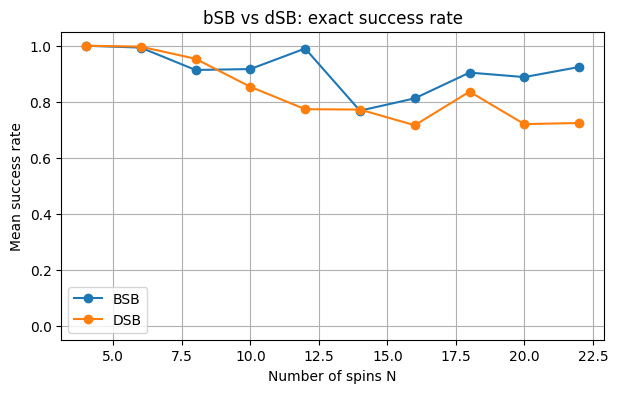

In [24]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_432_exact_all[
        summary_432_exact_all["variant"] == variant
    ]

    plt.plot(
        part["N"],
        part["mean_success_rate"],
        marker="o",
        label=variant,
    )

plt.xlabel("Number of spins N")
plt.ylabel("Mean success rate")
plt.title("bSB vs dSB: exact success rate")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()

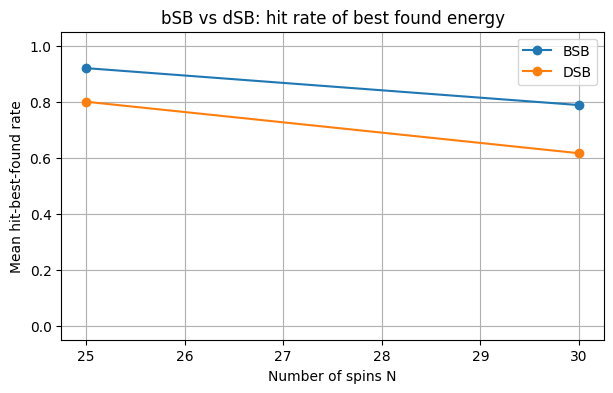

In [25]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_432_heuristic[
        summary_432_heuristic["variant"] == variant
    ]

    plt.plot(
        part["N"],
        part["mean_hit_best_rate"],
        marker="o",
        label=variant,
    )

plt.xlabel("Number of spins N")
plt.ylabel("Mean hit-best-found rate")
plt.title("bSB vs dSB: hit rate of best found energy")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()

In [26]:
results_432_exact_all.to_csv(
    "results_04_03_02_bsb_vs_dsb_exact_all.csv",
    index=False,
)

summary_432_exact_all.to_csv(
    "summary_04_03_02_bsb_vs_dsb_exact_all.csv",
    index=False,
)

results_432_heuristic_runs.to_csv(
    "results_04_03_02_bsb_vs_dsb_heuristic_runs.csv",
    index=False,
)

results_432_heuristic_summary_raw.to_csv(
    "results_04_03_02_bsb_vs_dsb_heuristic_summary_raw.csv",
    index=False,
)

summary_432_heuristic.to_csv(
    "summary_04_03_02_bsb_vs_dsb_heuristic.csv",
    index=False,
)

print("Saved all extended 4.3.2 results.")

Saved all extended 4.3.2 results.


In [27]:
summary_432_exact_display = summary_432_exact_all.copy()

cols_to_round = [
    "mean_success_rate",
    "median_success_rate",
    "mean_gap",
    "median_gap",
    "mean_best_gap",
    "mean_runtime_ms",
]

for col in cols_to_round:
    summary_432_exact_display[col] = summary_432_exact_display[col].round(4)

summary_432_exact_display

,N,variant,mean_success_rate,median_success_rate,mean_gap,median_gap,mean_best_gap,n_instances,mean_runtime_ms
0,4,BSB,1.0000,1.0000,0.0000,0.0,0.0,10,27.7127
1,4,DSB,1.0000,1.0000,0.0000,0.0,0.0,10,28.4797
2,6,BSB,0.9933,1.0000,0.0133,0.0,0.0,10,27.8346
3,6,DSB,0.9967,1.0000,0.0067,0.0,0.0,10,28.5652
4,8,BSB,0.9133,1.0000,0.1733,0.2,0.0,10,27.8492
5,8,DSB,0.9533,0.9667,0.2067,0.0,0.0,10,28.5779
6,10,BSB,0.9167,1.0000,0.1667,0.2,0.0,10,28.1013
7,10,DSB,0.8533,0.9167,0.4000,0.0,0.0,10,28.8140
8,12,BSB,0.9900,1.0000,0.0200,0.0,0.0,10,28.8438
9,12,DSB,0.7733,0.8167,0.7067,0.4,0.0,10,29.6303


In [28]:
summary_432_heuristic_display = summary_432_heuristic.copy()

cols_to_round = [
    "mean_hit_best_rate",
    "median_hit_best_rate",
    "mean_gap_to_best_found",
    "median_gap_to_best_found",
    "mean_best_gap_to_best_found",
    "mean_runtime_ms",
]

for col in cols_to_round:
    summary_432_heuristic_display[col] = summary_432_heuristic_display[col].round(4)

summary_432_heuristic_display

,N,variant,mean_hit_best_rate,median_hit_best_rate,mean_gap_to_best_found,median_gap_to_best_found,mean_best_gap_to_best_found,n_instances,mean_runtime_ms
0,25,BSB,0.920,0.94,0.488,0.0,0.0,5,29.2215
1,25,DSB,0.800,0.85,1.016,0.0,0.0,5,29.9401
2,30,BSB,0.788,0.84,0.700,0.2,0.0,5,29.5989
3,30,DSB,0.616,0.60,2.260,0.4,0.0,5,30.4373


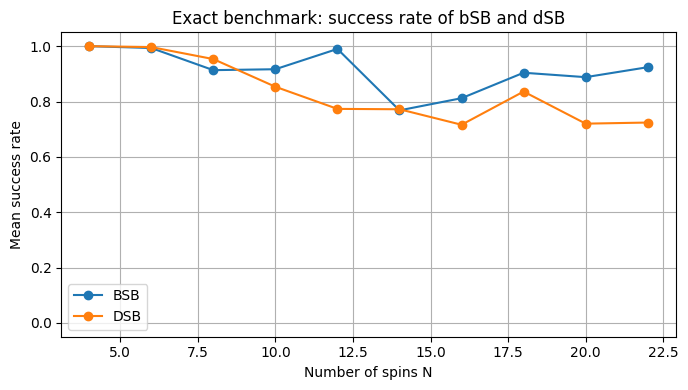

In [29]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_432_exact_all[
        summary_432_exact_all["variant"] == variant
    ].sort_values("N")

    plt.plot(
        part["N"],
        part["mean_success_rate"],
        marker="o",
        label=variant,
    )

plt.xlabel("Number of spins N")
plt.ylabel("Mean success rate")
plt.title("Exact benchmark: success rate of bSB and dSB")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_03_02_exact_success_rate.png", dpi=300)
plt.show()

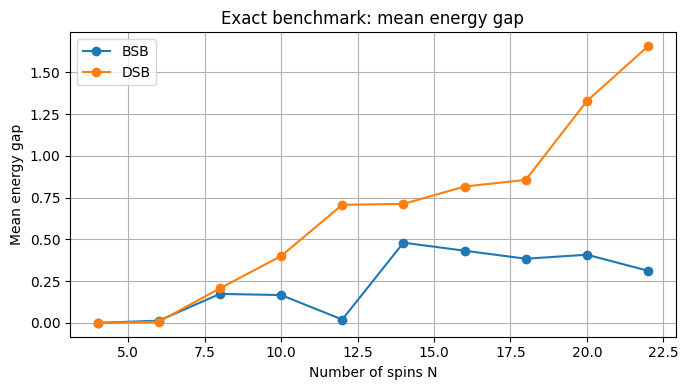

In [30]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_432_exact_all[
        summary_432_exact_all["variant"] == variant
    ].sort_values("N")

    plt.plot(
        part["N"],
        part["mean_gap"],
        marker="o",
        label=variant,
    )

plt.xlabel("Number of spins N")
plt.ylabel("Mean energy gap")
plt.title("Exact benchmark: mean energy gap")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_03_02_exact_mean_gap.png", dpi=300)
plt.show()

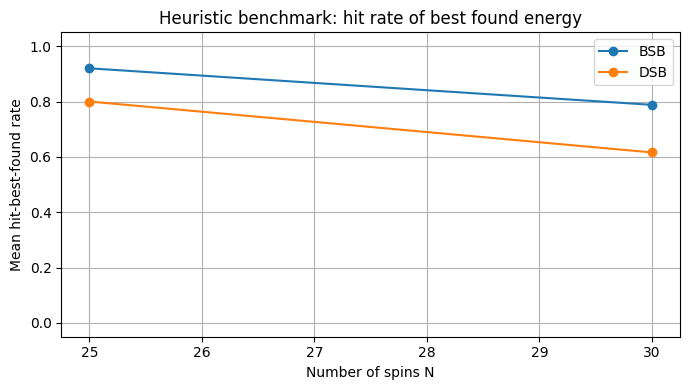

In [31]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_432_heuristic[
        summary_432_heuristic["variant"] == variant
    ].sort_values("N")

    plt.plot(
        part["N"],
        part["mean_hit_best_rate"],
        marker="o",
        label=variant,
    )

plt.xlabel("Number of spins N")
plt.ylabel("Mean hit-best-found rate")
plt.title("Heuristic benchmark: hit rate of best found energy")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_03_02_heuristic_hit_best_rate.png", dpi=300)
plt.show()

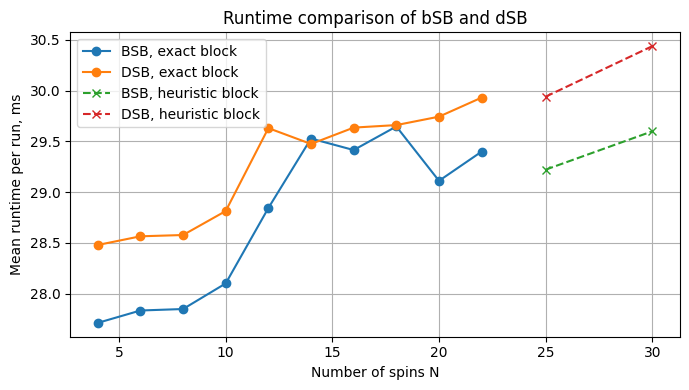

In [32]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_432_exact_all[
        summary_432_exact_all["variant"] == variant
    ].sort_values("N")

    plt.plot(
        part["N"],
        part["mean_runtime_ms"],
        marker="o",
        label=f"{variant}, exact block",
    )

for variant in ["BSB", "DSB"]:
    part = summary_432_heuristic[
        summary_432_heuristic["variant"] == variant
    ].sort_values("N")

    plt.plot(
        part["N"],
        part["mean_runtime_ms"],
        marker="x",
        linestyle="--",
        label=f"{variant}, heuristic block",
    )

plt.xlabel("Number of spins N")
plt.ylabel("Mean runtime per run, ms")
plt.title("Runtime comparison of bSB and dSB")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_03_02_runtime.png", dpi=300)
plt.show()